In [1]:
import pyccl as ccl
ccl.__version__
import numpy as np
import matplotlib.pylab as plt

# Create pyccl 'cosmo' object for different scenarios:

In [2]:
colors = ['darkred', 'darkorange', 'gold', 'yellowgreen', 'darkgreen']

#we will set two models- LCDM like:
cosmo = ccl.Cosmology(Omega_c= 0.25, Omega_b=0.05, 
                       h = 0.7, sigma8=0.8, n_s= 0.96, Omega_k=0.0) #cold-dark matter density, baryonic density, hubble constant/100, sigma8= matter power spectrum
#normalization at 8 Mpc/h, n_s = spectral index , Omega_k = curvature parameter - flat-geometry = 0!  
#Density of Dark energy = 1- Omega_m = 1 - (Omega_c+Omega_c) = 0.7


# Pressure = w density 
#For Dark energy in the Lambda-CDM --> w = -1 





#we will set two models- Dark energy variable using that the dark energy evolves like w=w0+wa(1-a):
cosmo_variable = ccl.Cosmology(Omega_c= 0.25, Omega_b=0.05, 
                       h=0.7, sigma8=0.8, n_s=0.96, Omega_k=0.0,
                       w0 = 0.3, wa= -.7, extra_parameters={"camb": {"dark_energy_model": "ppf"}})




# Pressure = w density 
#For Dynamic Dark energy model --> w = wo + wa*(1-a); a= scale factor (measurement of time)
# If LCDM is 'correct'---> wo = - 1, and wa = 0 




# Read the redshift distribution for a LSST-like survey (lens galaxies)

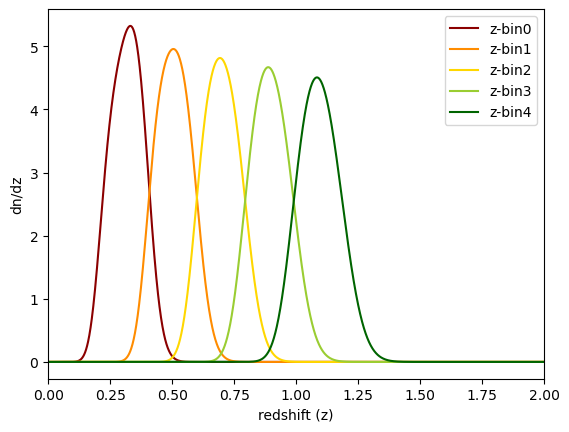

In [3]:
pz_path = '/home/s1/ggibbins/practice/lsst_like_dndz/' #where you saved the files from google drive

nside = 1024
ell = np.arange(0,  3*nside+1)

tracers_dndz = []
for i in range(5):
    zz, nz = np.load(pz_path+'NZ_lensgalaxies_bin_'+str(i)+'.npy')
    
    tracers_dndz.append(nz)
     
    plt.plot(zz,nz, label='z-bin'+str(i), color=colors[i])
plt.ylabel('dn/dz')
plt.xlabel('redshift (z)')
plt.legend()
plt.xlim(0, 2.0)

tracers_dndz = np.array(tracers_dndz)

# Once we know how the galaxies are distributed in terms of redshift, let's make the prediction about the power spectrum:

Text(0.5, 0, '$\\ell$')

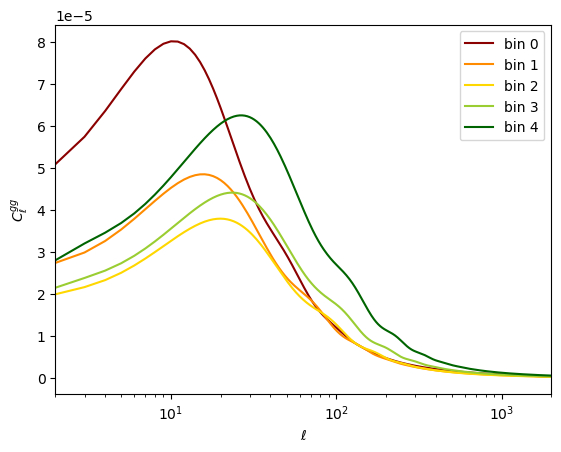

In [4]:
bias_z = [1.0, 1.1, 1.2, 1.5, 2.0]

ell = np.arange(3*1024+1)

for i in range(5):
    
    #Here it says that we are mapping galaxies, in a particular 'cosmo' scenario, with a specific dn/dz (redshift distribution) and a specific galaxy bias: 
    ccl_z = ccl.NumberCountsTracer(cosmo_variable,False,(zz,tracers_dndz[i]), bias= (zz,  bias_z[i]*np.ones(len(zz)) )) #<-- Here we use 'cosmo' consisting LCDM model, but we could
   
    #check for the cosmo_variable and check how it changes for different cosmologies...
    cl_gg_th = ccl.angular_cl(cosmo_variable, ccl_z,ccl_z, ell)

    plt.plot(ell, cl_gg_th, label='bin '+str(i), color=colors[i])
plt.xscale('log')
plt.xlim(2,2000)
plt.legend()
plt.ylabel(r'$C_{\ell}^{gg}$')
plt.xlabel(r'$\ell$')
    

# Next we would make a similar approach for other probes, such as CMB lensing and galaxy weak lensing.


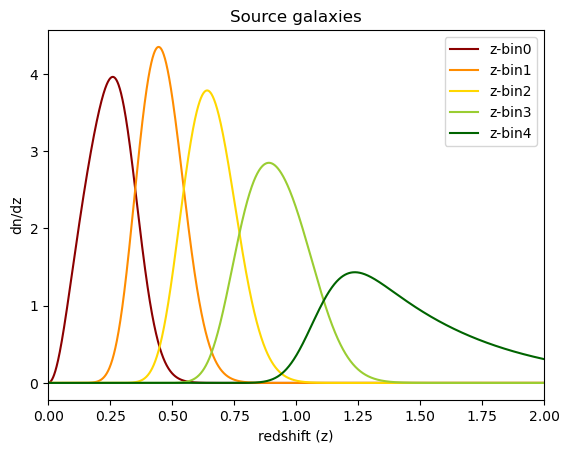

In [5]:
pz_path = '/home/s1/ggibbins/practice/lsst_like_dndz/' #where you saved the files from google drive

nside = 1024
ell = np.arange(0,  3*nside+1)

tracers_dndz_lens = []
for i in range(5):
    zz, nz = np.load(pz_path+'NZ_sourcegalaxies_bin_'+str(i)+'.npy', )
    
    tracers_dndz_lens.append(nz)
     
    plt.plot(zz,nz, label='z-bin'+str(i), color=colors[i])
plt.ylabel('dn/dz')
plt.xlabel('redshift (z)')
plt.title('Source galaxies')
plt.legend()
plt.xlim(0, 2.0)

tracers_dndz_lens = np.array(tracers_dndz_lens)

# Compute lensing power spectrum (Clkk = lens) and cross-correlation between galaxies and CMB lensing (Clgkcmb = gal_cmb) and galaxy lensing x CMB lensing (Cl kkcmb = lens_cmb)

In [6]:
#LCDM
cmb_lensing = ccl.CMBLensingTracer(cosmo, 1100) #(cosmology, cmb redshift)
ell = np.arange(3*1024+1)

lens_all = []
gal_cmb_all = []
lens_cmb_all = []

for i in range(5):
    
    #Here it says that we are mapping galaxies, in a particular 'cosmo' scenario, with a specific dn/dz (redshift distribution) and a specific galaxy bias: 
    ccl_z = ccl.NumberCountsTracer(cosmo,False,(zz,tracers_dndz[i]), bias= (zz,  bias_z[i]*np.ones(len(zz)) )) #gal
    ccl_z_lens = ccl.WeakLensingTracer(cosmo, (zz,tracers_dndz_lens[i])) #lens


    lens_th = ccl.angular_cl(cosmo, ccl_z_lens,ccl_z_lens, ell)
    lens_all.append(lens_th) #weak lensing x weak lensing

    #Cross-correlation between CMB and galaxies
    gal_cmb_th = ccl.angular_cl(cosmo, ccl_z,cmb_lensing, ell)
    gal_cmb_all.append(gal_cmb_th)
    #Cross-correlation between CMB and galaxy weak lensing
    lens_cmb_th = ccl.angular_cl(cosmo, ccl_z_lens,cmb_lensing, ell)
    lens_cmb_all.append(lens_cmb_th)


lens_all = np.array(lens_all)
gal_cmb_all = np.array(gal_cmb_all)
lens_cmb_all = np.array(lens_cmb_all)

In [7]:
#SAME AS ABOVE BUT W DDE
dde_cmb_lensing = ccl.CMBLensingTracer(cosmo_variable, 1100) #(cosmology, cmb redshift)
ell = np.arange(3*1024+1)

dde_lens_all = []
dde_gal_cmb_all = []
dde_lens_cmb_all = []

for i in range(5):
    
    #Here it says that we are mapping galaxies, in a particular 'cosmo' scenario, with a specific dn/dz (redshift distribution) and a specific galaxy bias: 
    dde_ccl_z = ccl.NumberCountsTracer(cosmo_variable,False,(zz,tracers_dndz[i]), bias= (zz,  bias_z[i]*np.ones(len(zz)) )) #gal
    dde_ccl_z_lens = ccl.WeakLensingTracer(cosmo_variable, (zz,tracers_dndz_lens[i])) #lens


    dde_lens_th = ccl.angular_cl(cosmo_variable, dde_ccl_z_lens,dde_ccl_z_lens, ell)
    dde_lens_all.append(dde_lens_th) #weak lensing x weak lensing

    #Cross-correlation between CMB and galaxies
    dde_gal_cmb_th = ccl.angular_cl(cosmo_variable, dde_ccl_z,cmb_lensing, ell)
    dde_gal_cmb_all.append(dde_gal_cmb_th)
    #Cross-correlation between CMB and galaxy weak lensing
    dde_lens_cmb_th = ccl.angular_cl(cosmo_variable, dde_ccl_z_lens,dde_cmb_lensing, ell)
    dde_lens_cmb_all.append(dde_lens_cmb_th)


dde_lens_all = np.array(dde_lens_all)
dde_gal_cmb_all = np.array(dde_gal_cmb_all)
dde_lens_cmb_all = np.array(dde_lens_cmb_all)

Text(0.5, 1.0, 'Galaxy x CMB Lensing PS')

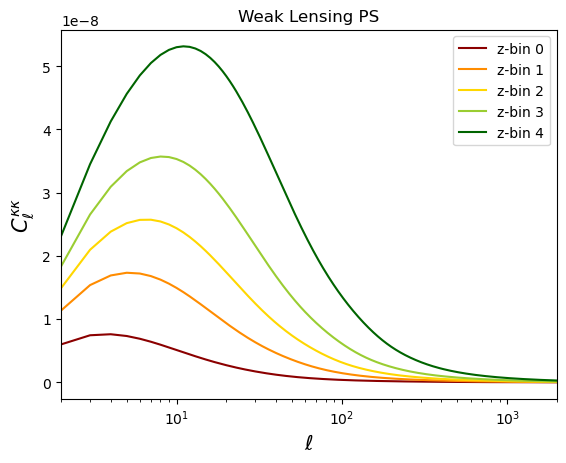

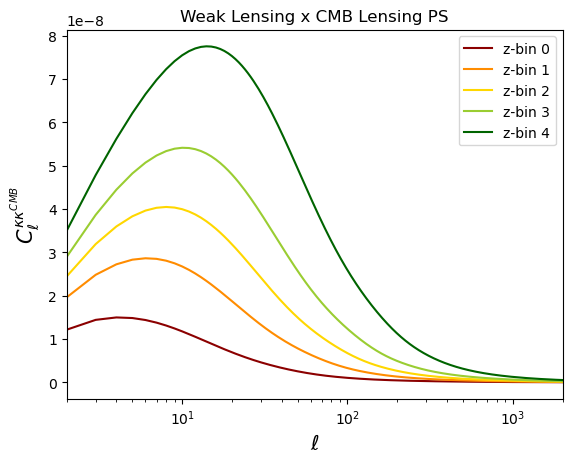

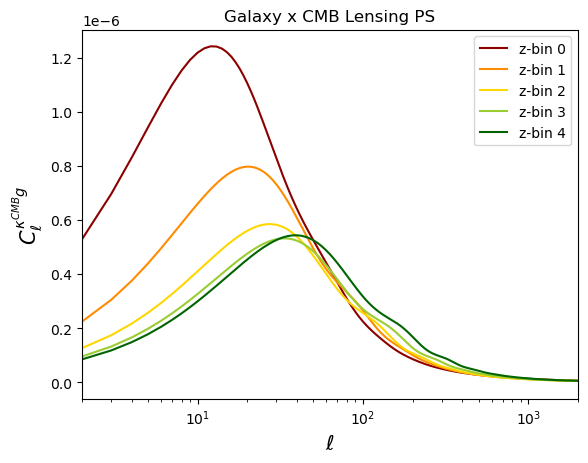

In [8]:
plt.figure()

for i in range(5):
    plt.plot(ell, lens_all[i], label='z-bin '+str(i), color=colors[i])
    plt.xscale('log')
plt.xlim(2,2000)
plt.legend()
plt.ylabel(r'$C_{\ell}^{\kappa\kappa}$', fontsize=15)
plt.xlabel(r'$\ell$', fontsize=15)
plt.title('Weak Lensing PS')


plt.figure()

for i in range(5):
    plt.plot(ell, lens_cmb_all[i], label='z-bin '+str(i), color=colors[i])
    plt.xscale('log')
plt.xlim(2,2000)
plt.legend()
plt.ylabel(r'$C_{\ell}^{\kappa\kappa^{CMB}}$', fontsize=15)
plt.xlabel(r'$\ell$', fontsize=15)
plt.title('Weak Lensing x CMB Lensing PS')


plt.figure()

for i in range(5):
    plt.plot(ell, gal_cmb_all[i], label='z-bin '+str(i), color=colors[i])
    plt.xscale('log')
plt.xlim(2,2000)
plt.legend()
plt.ylabel(r'$C_{\ell}^{\kappa^{CMB} g}$', fontsize=15)
plt.xlabel(r'$\ell$', fontsize=15)
plt.title('Galaxy x CMB Lensing PS')

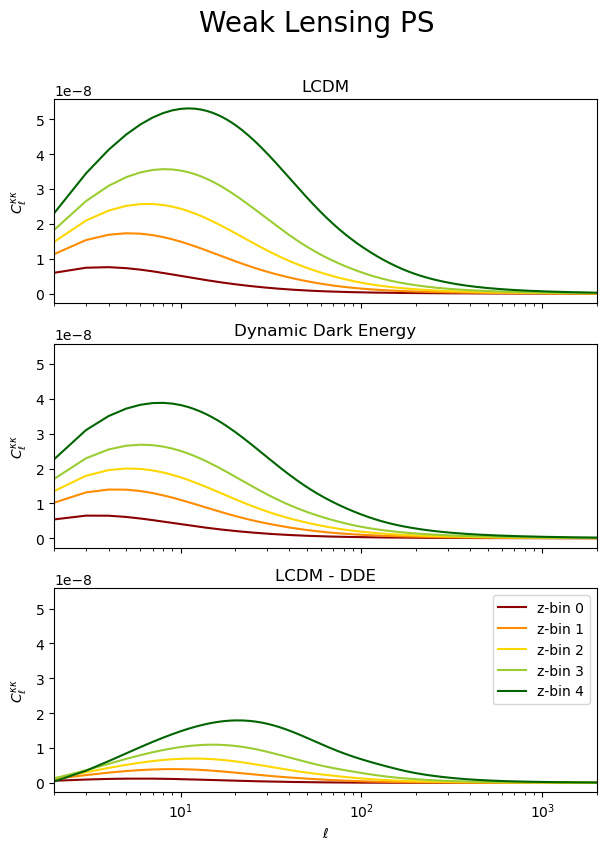

In [9]:
fig, axs = plt.subplots(3,sharex=True,sharey=True, figsize=(7,9)) #sharey=false to see differences in more detail (true shows scale better)

fig.suptitle("Weak Lensing PS", fontsize=20)

for i in range(5):
    axs[0].plot(ell, lens_all[i], label='z-bin '+str(i), color=colors[i])
    axs[1].plot(ell, dde_lens_all[i], label='z-bin '+str(i), color=colors[i])
    diff = lens_all[i] - dde_lens_all[i]
    axs[2].plot(ell, diff, label='z-bin '+str(i), color=colors[i])
    plt.xscale('log')

plt.xlim(2,2000)
axs[0].set_ylabel(r'$C_{\ell}^{\kappa\kappa}$')
axs[1].set_ylabel(r'$C_{\ell}^{\kappa\kappa}$')
axs[2].set_ylabel(r'$C_{\ell}^{\kappa\kappa}$')
plt.xlabel(r'$\ell$')
axs[0].set_title("LCDM")
axs[1].set_title("Dynamic Dark Energy")
axs[2].set_title("LCDM - DDE")
plt.legend()

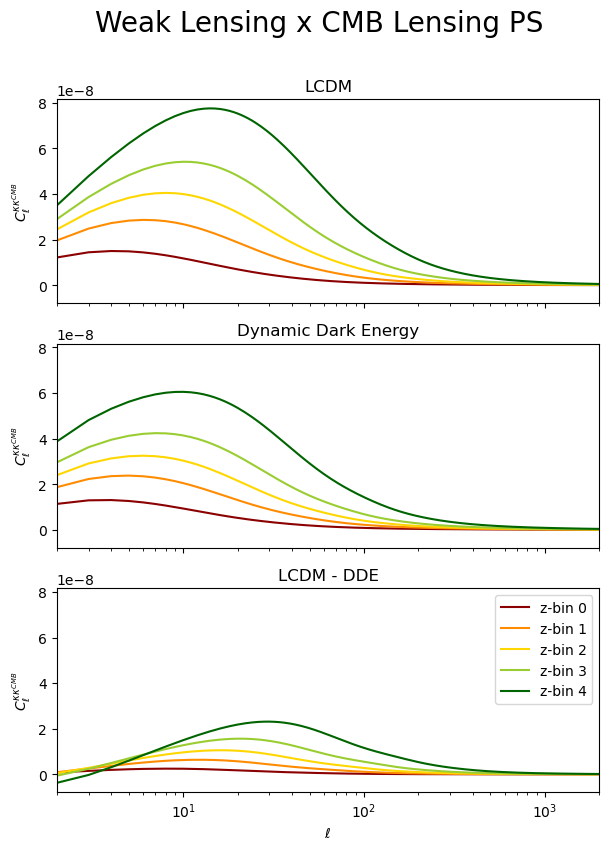

In [10]:
fig, axs = plt.subplots(3,sharex=True, sharey=True, figsize=(7,9)) #sharey=false to see differences in more detail (true shows scale better)

fig.suptitle("Weak Lensing x CMB Lensing PS", fontsize=20)

for i in range(5):
    axs[0].plot(ell, lens_cmb_all[i], label='z-bin '+str(i), color=colors[i])
    axs[1].plot(ell, dde_lens_cmb_all[i], label='z-bin '+str(i), color=colors[i])
    diff = lens_cmb_all[i] - dde_lens_cmb_all[i]
    axs[2].plot(ell, diff, label='z-bin '+str(i), color=colors[i])
    plt.xscale('log')

plt.xlim(2,2000)
axs[0].set_ylabel(r'$C_{\ell}^{\kappa\kappa^{CMB}}$')
axs[1].set_ylabel(r'$C_{\ell}^{\kappa\kappa^{CMB}}$')
axs[2].set_ylabel(r'$C_{\ell}^{\kappa\kappa^{CMB}}$')
plt.xlabel(r'$\ell$')
axs[0].set_title("LCDM")
axs[1].set_title("Dynamic Dark Energy")
axs[2].set_title("LCDM - DDE")
plt.legend()


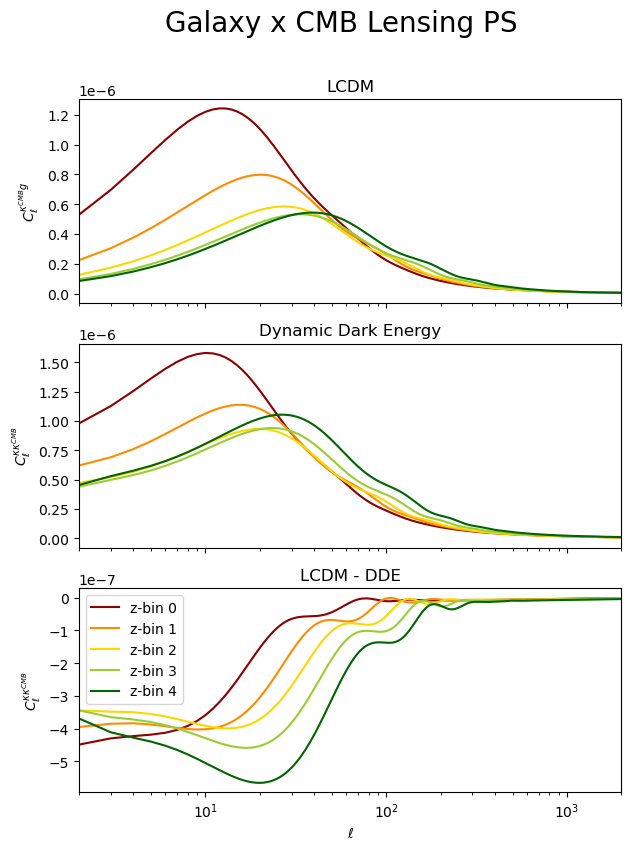

In [11]:
fig, axs = plt.subplots(3,sharex=True, figsize=(7,9)) #sharey=false to see differences in more detail (true shows scale better)

fig.suptitle("Galaxy x CMB Lensing PS", fontsize=20)

for i in range(5):
    axs[0].plot(ell, gal_cmb_all[i], label='z-bin '+str(i), color=colors[i])
    axs[1].plot(ell, dde_gal_cmb_all[i], label='z-bin '+str(i), color=colors[i])
    diff = gal_cmb_all[i] - dde_gal_cmb_all[i]
    axs[2].plot(ell, diff, label='z-bin '+str(i), color=colors[i])
    plt.xscale('log')

plt.xlim(2,2000)
axs[0].set_ylabel(r'$C_{\ell}^{\kappa^{CMB} g}$')
axs[1].set_ylabel(r'$C_{\ell}^{\kappa\kappa^{CMB}}$')
axs[2].set_ylabel(r'$C_{\ell}^{\kappa\kappa^{CMB}}$')
plt.xlabel(r'$\ell$')
axs[0].set_title("LCDM")
axs[1].set_title("Dynamic Dark Energy")
axs[2].set_title("LCDM - DDE")
plt.legend()
#plt.savefig('/home/s1/ggibbins/paramplots/galxcmb')

'\naxs[0].set_ylabel(r\'$C_{\\ell}^{\\kappa\\kappa^{CMB}}$\')\naxs[1].set_ylabel(r\'$C_{\\ell}^{\\kappa\\kappa^{CMB}}$\')\naxs[2].set_ylabel(r\'$C_{\\ell}^{\\kappa\\kappa^{CMB}}$\')\naxs[3].set_ylabel(r\'$C_{\\ell}^{\\kappa\\kappa^{CMB}}$\')\naxs[4].set_ylabel(r\'$C_{\\ell}^{\\kappa\\kappa^{CMB}}$\')\nplt.xlabel(r\'$\\ell$\')\naxs[0].set_title("Z-Bin 0")\naxs[1].set_title("Z-Bin 1")\naxs[2].set_title("Z-Bin 2")\naxs[3].set_title("Z-Bin 3")\naxs[4].set_title("Z-Bin 4")\n'

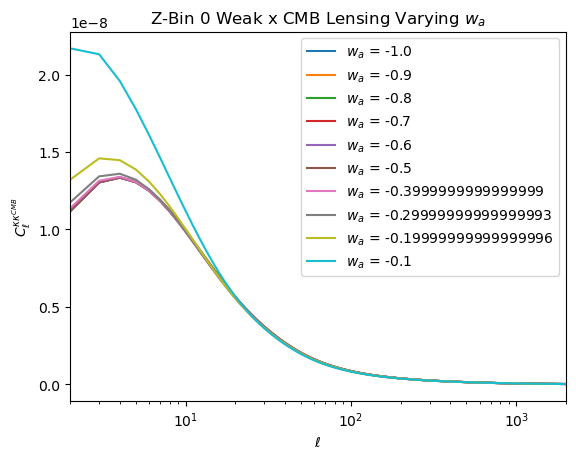

In [12]:
#Vary wa with all other cosmo fixed BIN 0

'''
fig, axs = plt.subplots(5,sharex=True,sharey=True, figsize=(7,9)) #sharey=false to see differences in more detail (true shows scale better)

fig.suptitle("Weak x CMB Lensing PS Varying $w_{a}$", fontsize=20)
'''

waa = np.linspace(-1,-.1, num=10)

cosmo_wa = []

#Creates 10 cosmologies varying wa from -1 to -.1 inside cosmo_wa list
for i in range(10):
    cosmo_wa_in = ccl.Cosmology(Omega_c= 0.25, Omega_b=0.05, 
                       h=0.7, sigma8=0.8, n_s=0.96, Omega_k=0.0,
                       w0 = 0, wa= waa[i], extra_parameters={"camb": {"dark_energy_model": "ppf"}})
    cosmo_wa.append(cosmo_wa_in)

#Iterates through cosmo_wa list to create a cross ps for each wa value
for i in range(10):
    cmb_lensing = ccl.CMBLensingTracer(cosmo_wa[i], 1100) #(cosmology, cmb redshift, n samples)
    lens = ccl.WeakLensingTracer(cosmo_wa[i], (zz,tracers_dndz_lens[0])) #DO I NEED TO CHANGE ZZ OR IT THRU FOR J Z BIN 0
    lens_cmb_wa = ccl.angular_cl(cosmo_wa[i], lens, cmb_lensing, ell)
    #dde_lens_cmb_all.append(dde_lens_cmb_th)
    
    plt.plot(ell, lens_cmb_wa, label='$w_{a}$ = '+str(waa[i]))


plt.xscale('log')
plt.xlim(2,2000)
plt.legend()
plt.title('Z-Bin 0 Weak x CMB Lensing Varying $w_{a}$')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$C_{\ell}^{\kappa\kappa^{CMB}}$')

'''
axs[0].set_ylabel(r'$C_{\ell}^{\kappa\kappa^{CMB}}$')
axs[1].set_ylabel(r'$C_{\ell}^{\kappa\kappa^{CMB}}$')
axs[2].set_ylabel(r'$C_{\ell}^{\kappa\kappa^{CMB}}$')
axs[3].set_ylabel(r'$C_{\ell}^{\kappa\kappa^{CMB}}$')
axs[4].set_ylabel(r'$C_{\ell}^{\kappa\kappa^{CMB}}$')
plt.xlabel(r'$\ell$')
axs[0].set_title("Z-Bin 0")
axs[1].set_title("Z-Bin 1")
axs[2].set_title("Z-Bin 2")
axs[3].set_title("Z-Bin 3")
axs[4].set_title("Z-Bin 4")
'''

Text(0.5, 1.0, 'Z-Bin 4')

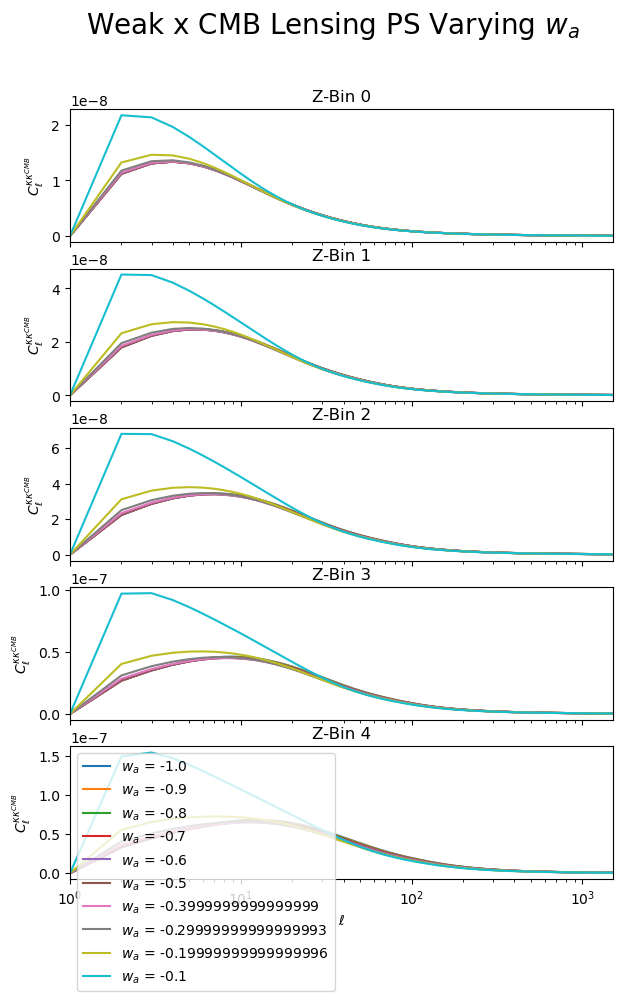

In [19]:
#Vary wa with all other cosmo fixed

fig, axs = plt.subplots(5,sharex=True, figsize=(7,10)) #sharey=false to see differences in more detail (true shows scale better)

fig.suptitle("Weak x CMB Lensing PS Varying $w_{a}$", fontsize=20)

waa = np.linspace(-1,-.1, num=10)

cosmo_wa = []

#Creates 10 cosmologies varying wa from -1 to 0 inside cosmo_wa list
for i in range(10):
    cosmo_wa_in = ccl.Cosmology(Omega_c= 0.25, Omega_b=0.05, 
                       h=0.7, sigma8=0.8, n_s=0.96, Omega_k=0.0,
                       w0 = 0, wa= waa[i], extra_parameters={"camb": {"dark_energy_model": "ppf"}})
    cosmo_wa.append(cosmo_wa_in)


#Iterates through cosmo_wa list to create a cross ps for each wa value
for i in range(10):
    cmb_lensing = ccl.CMBLensingTracer(cosmo_wa[i], 1100) #(cosmology, cmb redshift)
    lens_0 = ccl.WeakLensingTracer(cosmo_wa[i], (zz,tracers_dndz_lens[0]))
    lens_1 = ccl.WeakLensingTracer(cosmo_wa[i], (zz,tracers_dndz_lens[1]))
    lens_2 = ccl.WeakLensingTracer(cosmo_wa[i], (zz,tracers_dndz_lens[2]))
    lens_3 = ccl.WeakLensingTracer(cosmo_wa[i], (zz,tracers_dndz_lens[3]))
    lens_4 = ccl.WeakLensingTracer(cosmo_wa[i], (zz,tracers_dndz_lens[4]))
    lens_cmb_wa_0 = ccl.angular_cl(cosmo_wa[i], lens_0,cmb_lensing, ell)
    lens_cmb_wa_1 = ccl.angular_cl(cosmo_wa[i], lens_1,cmb_lensing, ell)
    lens_cmb_wa_2 = ccl.angular_cl(cosmo_wa[i], lens_2,cmb_lensing, ell)
    lens_cmb_wa_3 = ccl.angular_cl(cosmo_wa[i], lens_3,cmb_lensing, ell)
    lens_cmb_wa_4 = ccl.angular_cl(cosmo_wa[i], lens_4,cmb_lensing, ell)
    axs[0].plot(ell, lens_cmb_wa_0, label='$w_{a}$ = '+str(waa[i]))
    axs[1].plot(ell, lens_cmb_wa_1, label='$w_{a}$ = '+str(waa[i]))
    axs[2].plot(ell, lens_cmb_wa_2, label='$w_{a}$ = '+str(waa[i]))
    axs[3].plot(ell, lens_cmb_wa_3, label='$w_{a}$ = '+str(waa[i]))
    axs[4].plot(ell, lens_cmb_wa_4, label='$w_{a}$ = '+str(waa[i]))

plt.xscale('log')
plt.xlim(1,1500)
plt.legend()
plt.title('Z-Bin 1 Weak x CMB Lensing Varying $w_{a}$')

axs[0].set_ylabel(r'$C_{\ell}^{\kappa\kappa^{CMB}}$')
axs[1].set_ylabel(r'$C_{\ell}^{\kappa\kappa^{CMB}}$')
axs[2].set_ylabel(r'$C_{\ell}^{\kappa\kappa^{CMB}}$')
axs[3].set_ylabel(r'$C_{\ell}^{\kappa\kappa^{CMB}}$')
axs[4].set_ylabel(r'$C_{\ell}^{\kappa\kappa^{CMB}}$')
plt.xlabel(r'$\ell$')
axs[0].set_title("Z-Bin 0")
axs[1].set_title("Z-Bin 1")
axs[2].set_title("Z-Bin 2")
axs[3].set_title("Z-Bin 3")
axs[4].set_title("Z-Bin 4")

[0.1        0.18888889 0.27777778 0.36666667 0.45555556 0.54444444
 0.63333333 0.72222222 0.81111111 0.9       ]


NameError: name 'lens_cmb_ob_0' is not defined

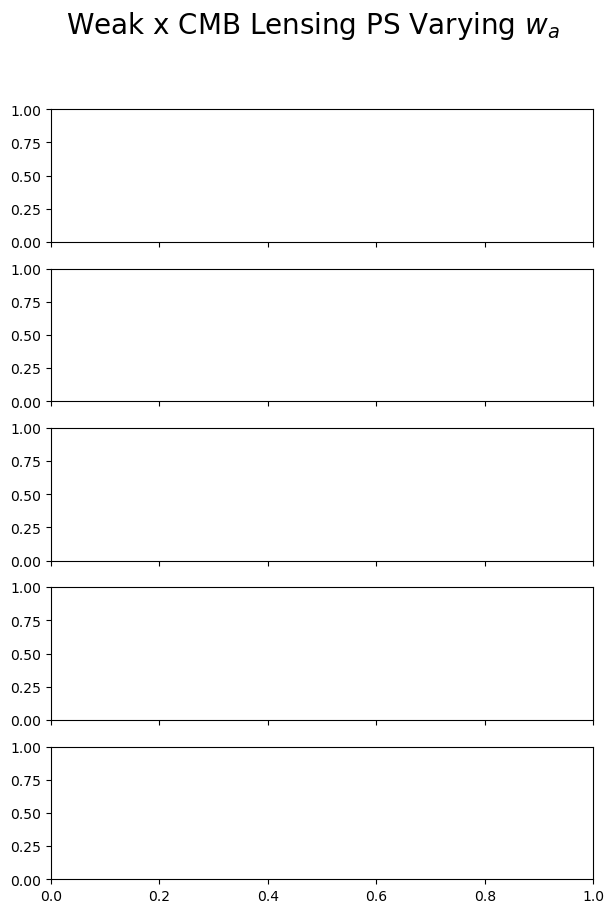

In [34]:
#Vary wa with all other cosmo fixed

fig, axs = plt.subplots(5,sharex=True, figsize=(7,10)) #sharey=false to see differences in more detail (true shows scale better)

fig.suptitle("Weak x CMB Lensing PS Varying $w_{a}$", fontsize=20)

ob = np.linspace(.1,.9, num=10)
print(ob)
cosmo_ob = []

#Creates 10 cosmologies varying wa from  inside cosmo_ob list
for i in range(10):
    cosmo_ob_in = ccl.Cosmology(Omega_c= 0.25, Omega_b= ob[i], 
                       h=0.7, sigma8=0.8, n_s=0.96, Omega_k=0.0,
                       w0 = -.3, wa= -.6, extra_parameters={"camb": {"dark_energy_model": "ppf"}})
    cosmo_ob.append(cosmo_ob_in)


#Iterates through cosmo_ob list to create a cross ps for each wa value
for i in range(10):
    cmb_lensing = ccl.CMBLensingTracer(cosmo_ob[i], 1100) #(cosmology, cmb redshift)
    lens_0 = ccl.WeakLensingTracer(cosmo_ob[i], (zz,tracers_dndz_lens[0]))
    lens_1 = ccl.WeakLensingTracer(cosmo_ob[i], (zz,tracers_dndz_lens[1]))
    lens_2 = ccl.WeakLensingTracer(cosmo_ob[i], (zz,tracers_dndz_lens[2]))
    lens_3 = ccl.WeakLensingTracer(cosmo_ob[i], (zz,tracers_dndz_lens[3]))
    lens_4 = ccl.WeakLensingTracer(cosmo_ob[i], (zz,tracers_dndz_lens[4]))
    lens_cmb_wa_0 = ccl.angular_cl(cosmo_ob[i], lens_0,cmb_lensing, ell)
    lens_cmb_wa_1 = ccl.angular_cl(cosmo_ob[i], lens_1,cmb_lensing, ell)
    lens_cmb_wa_2 = ccl.angular_cl(cosmo_ob[i], lens_2,cmb_lensing, ell)
    lens_cmb_wa_3 = ccl.angular_cl(cosmo_ob[i], lens_3,cmb_lensing, ell)
    lens_cmb_wa_4 = ccl.angular_cl(cosmo_ob[i], lens_4,cmb_lensing, ell)
    axs[0].plot(ell, lens_cmb_ob_0, label='ob = '+str(waa[i]))
    axs[1].plot(ell, lens_cmb_ob_1, label='ob = '+str(waa[i]))
    axs[2].plot(ell, lens_cmb_ob_2, label='ob = '+str(waa[i]))
    axs[3].plot(ell, lens_cmb_ob_3, label='ob = '+str(waa[i]))
    axs[4].plot(ell, lens_cmb_ob_4, label='ob = '+str(waa[i]))

plt.xscale('log')
plt.xlim(2,2000)
plt.legend()
plt.title('Z-Bin 1 Weak x CMB Lensing Varying ob')

axs[0].set_ylabel(r'$C_{\ell}^{\kappa\kappa^{CMB}}$')
axs[1].set_ylabel(r'$C_{\ell}^{\kappa\kappa^{CMB}}$')
axs[2].set_ylabel(r'$C_{\ell}^{\kappa\kappa^{CMB}}$')
axs[3].set_ylabel(r'$C_{\ell}^{\kappa\kappa^{CMB}}$')
axs[4].set_ylabel(r'$C_{\ell}^{\kappa\kappa^{CMB}}$')
plt.xlabel(r'$\ell$')
axs[0].set_title("Z-Bin 0")
axs[1].set_title("Z-Bin 1")
axs[2].set_title("Z-Bin 2")
axs[3].set_title("Z-Bin 3")
axs[4].set_title("Z-Bin 4")